# 05: Adaptive Conformal Inference (ACI)

## Goals
1. Generate synthetic non-stationary data with regime-dependent noise (calm/crisis periods)
2. Show that static split conformal fails — undercoverage during crisis, overcoverage during calm
3. Implement ACI from Gibbs and Candes (2021): α_{t+1} = α_t + γ(α - err_t)
4. Verify: ACI achieves long-run marginal coverage despite non-stationarity
5. Demonstrate the gap: ACI fixes marginal coverage but still has poor per-regime coverage — motivating the regime-conditional approach

## Setup
- Synthetic time series with two regimes: low noise (σ = 1) and high noise (σ = 3)
- Regime switches at known time points
- Base predictor fit on early stable data
- α = 0.1 (target 90% coverage)
- Step size γ to be explored

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

np.random.seed(42)

# Generate non-stationary time series
# y_t = 0.5 * x_t + noise_t where noise variance switches between regimes
N = 1000

# Regime schedule: calm (0-300), crisis (300-500), calm (500-700), crisis (700-850), calm (850-1000)
regimes = np.zeros(N, dtype=int)
regimes[300:500] = 1
regimes[700:850] = 1

# Features: simple autoregressive
X = np.random.normal(0, 1, N)

# Noise: regime-dependent variance
sigma_regime = np.where(regimes == 0, 1.0, 3.0)
noise = np.random.normal(0, sigma_regime)

# Observations
Y = 0.5 * X + noise

In [2]:
# Training data: first 200 points (stable calm period)
X_train = X[:200]
Y_train = Y[:200]

# Fit linear regression
coeffs = np.polyfit(X_train, Y_train, deg=1)
predict = np.poly1d(coeffs)

In [7]:
# Calibration data set on 200-300, training on 300-1000
X_cal, Y_cal = X[200:300], Y[200:300]
X_test, Y_test = X[300:], Y[300:]

In [8]:
# First trying this dataset on previous static conformal to compare performance later

alpha = 0.1
# Nonconformity scores on calibration set
scores = np.abs(Y_cal - predict(X_cal))
# Q_hat(1 - alpha) - empirical quantile of calibration scores
q_hat = np.quantile(scores, 1 - alpha)

lower = predict(X_test) - q_hat
upper = predict(X_test) + q_hat
coverage = np.mean((Y_test >= lower) & (Y_test <= upper))
print(f"Empirical coverage: {coverage:.4f} (target: {1 - alpha:.2f})")

Empirical coverage: 0.6629 (target: 0.90)


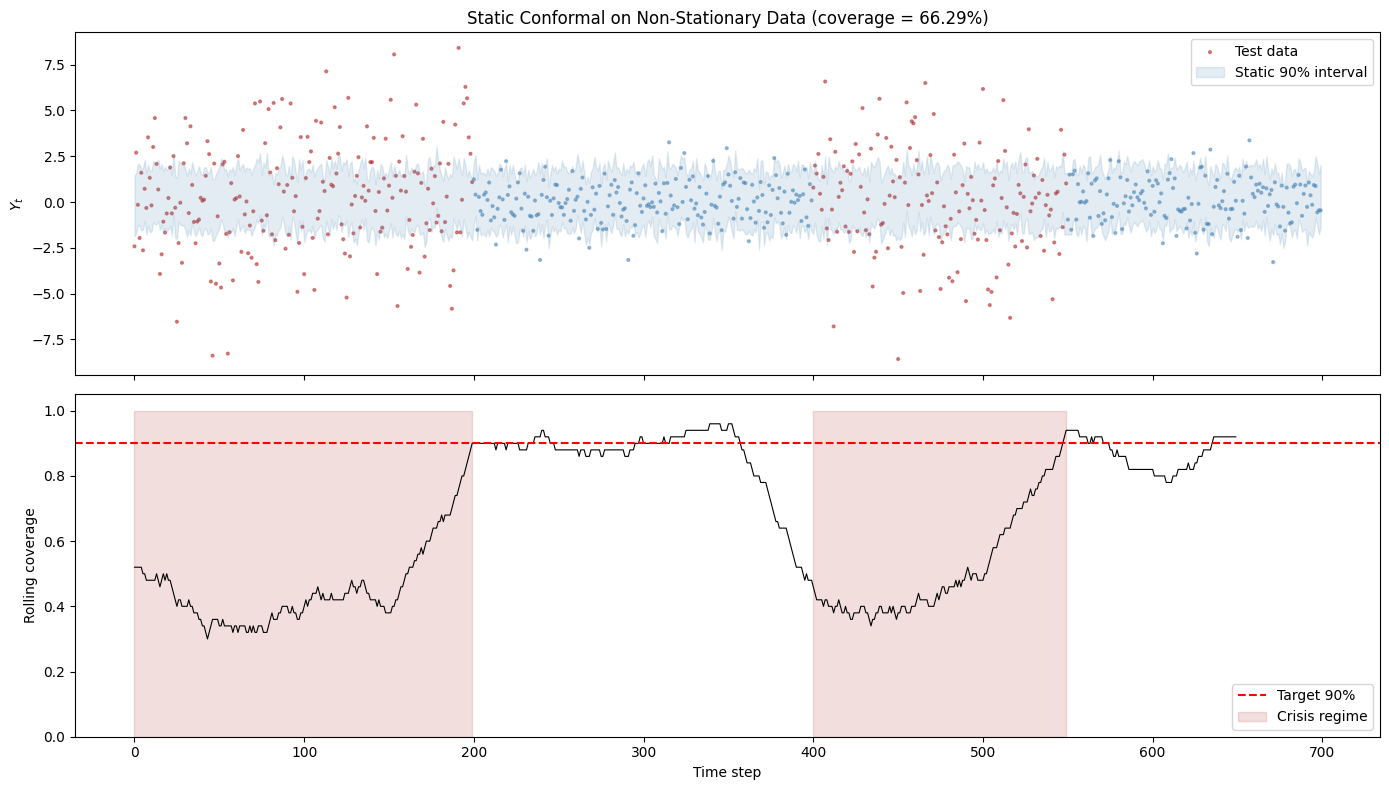

In [9]:
test_regimes = regimes[300:]
N_test = len(X_test)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Top: predictions and intervals
ax1.scatter(range(N_test), Y_test, s=4, alpha=0.5, c=np.where(test_regimes == 0, 'steelblue', 'firebrick'), label='Test data')
ax1.fill_between(range(N_test), lower, upper, alpha=0.15, color='steelblue', label='Static 90% interval')
ax1.set_ylabel('$Y_t$')
ax1.set_title(f'Static Conformal on Non-Stationary Data (coverage = {coverage:.2%})')
ax1.legend()

# Bottom: rolling coverage in windows of 50
window = 50
rolling_coverage = np.array([
    np.mean((Y_test[i:i+window] >= lower[i:i+window]) & (Y_test[i:i+window] <= upper[i:i+window]))
    for i in range(0, N_test - window)
])
ax2.plot(rolling_coverage, color='black', linewidth=0.8)
ax2.axhline(0.9, color='red', linestyle='--', label='Target 90%')
ax2.fill_between(range(len(test_regimes) - window), 0, 1, 
                  where=test_regimes[:len(test_regimes)-window]==1, alpha=0.15, color='firebrick', label='Crisis regime')
ax2.set_ylabel('Rolling coverage')
ax2.set_xlabel('Time step')
ax2.set_ylim(0, 1.05)
ax2.legend()

plt.tight_layout()
plt.show()

In [10]:
gamma_aci = 0.005  # step size 
alpha_target = 0.1
alpha_t = alpha_target  # initialize at target

# We need a running collection of recent scores to compute quantiles from
# Start with the calibration scores
score_history = list(scores)

In [11]:
# Storage
alpha_trajectory = []
aci_lower = np.zeros(N_test)
aci_upper = np.zeros(N_test)
aci_covered = np.zeros(N_test)

In [14]:
for t in range(N_test):
    # Build interval using current alpha_t
    q_t = np.quantile(score_history, min(max(1-alpha_t, 0), 1))
    aci_lower[t] = predict(X_test[t]) - q_t
    aci_upper[t] = predict(X_test[t]) + q_t

    # Check coverage
    err_t = 1 if (Y_test[t] < aci_lower[t] or Y_test[t] > aci_upper[t]) else 0
    aci_covered[t] = 1- err_t

    # Update alpha
    alpha_t = alpha_t + gamma_aci * (alpha_target - err_t)
    alpha_trajectory.append(alpha_t)

    # Add new score to history
    new_score = np.abs(Y_test[t] - predict(X_test[t]))
    score_history.append(new_score)

aci_coverage = np.mean(aci_covered)
print(f"ACI coverage: {aci_coverage:.4f} (target: {1 - alpha_target:.2f})")

ACI coverage: 0.9271 (target: 0.90)


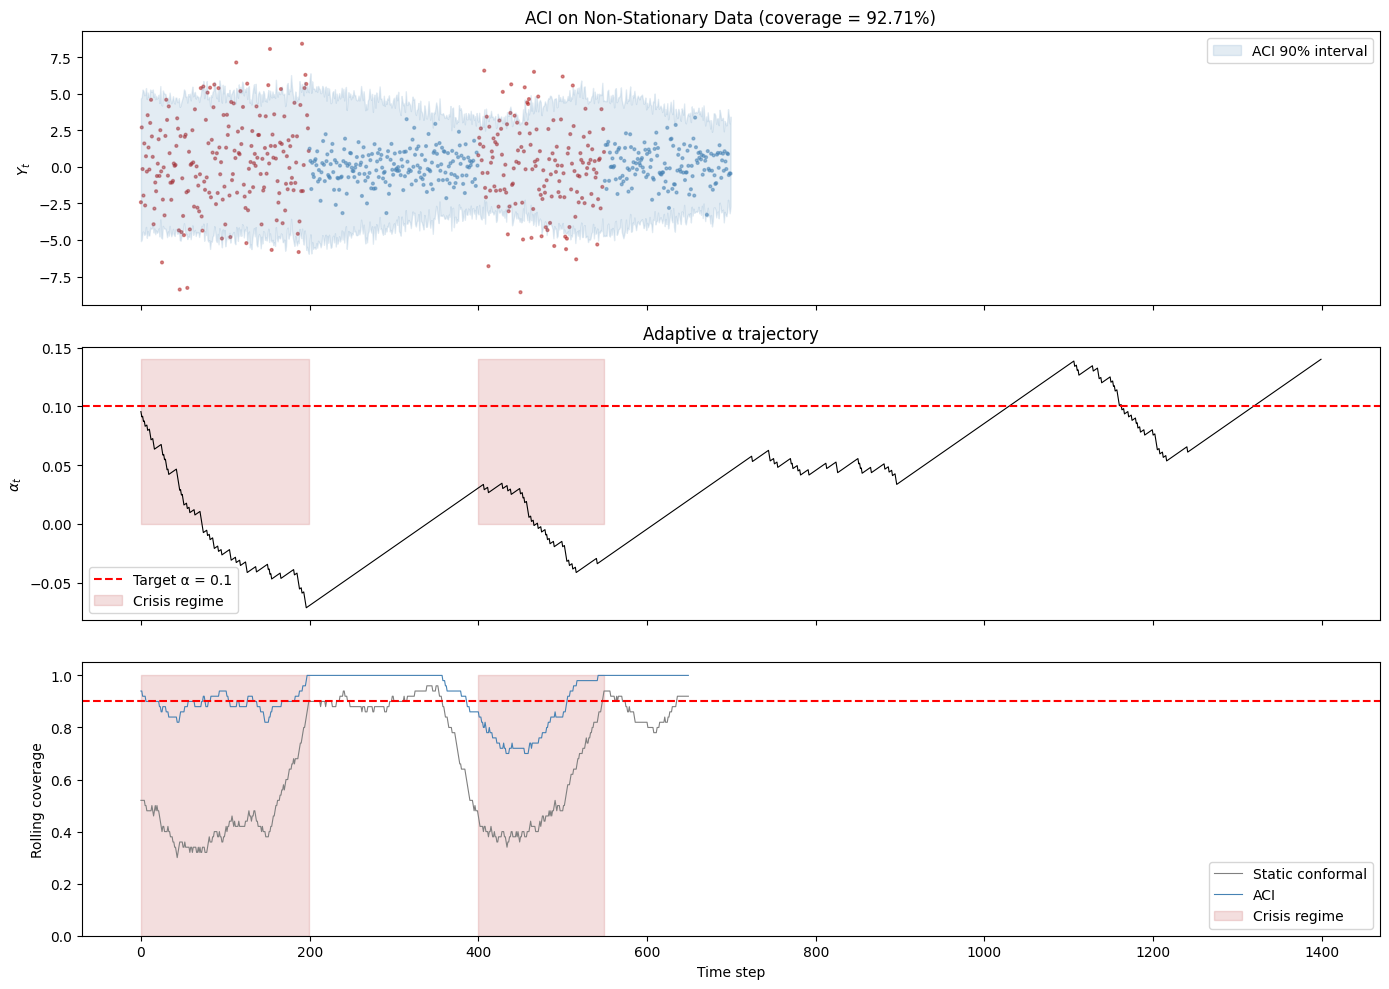

In [15]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Top: ACI intervals
ax1.scatter(range(N_test), Y_test, s=4, alpha=0.5, c=np.where(test_regimes == 0, 'steelblue', 'firebrick'))
ax1.fill_between(range(N_test), aci_lower, aci_upper, alpha=0.15, color='steelblue', label='ACI 90% interval')
ax1.set_ylabel('$Y_t$')
ax1.set_title(f'ACI on Non-Stationary Data (coverage = {aci_coverage:.2%})')
ax1.legend()

# Middle: alpha_t trajectory
ax2.plot(alpha_trajectory, color='black', linewidth=0.8)
ax2.axhline(alpha_target, color='red', linestyle='--', label='Target α = 0.1')
ax2.fill_between(range(N_test), 0, max(alpha_trajectory),
                  where=test_regimes == 1, alpha=0.15, color='firebrick', label='Crisis regime')
ax2.set_ylabel('$\\alpha_t$')
ax2.set_title('Adaptive α trajectory')
ax2.legend()

# Bottom: rolling coverage comparison
window = 50
rolling_static = np.array([
    np.mean((Y_test[i:i+window] >= lower[i:i+window]) & (Y_test[i:i+window] <= upper[i:i+window]))
    for i in range(N_test - window)
])
rolling_aci = np.array([
    np.mean(aci_covered[i:i+window])
    for i in range(N_test - window)
])
ax3.plot(rolling_static, color='grey', linewidth=0.8, label='Static conformal')
ax3.plot(rolling_aci, color='steelblue', linewidth=0.8, label='ACI')
ax3.axhline(0.9, color='red', linestyle='--')
ax3.fill_between(range(N_test - window), 0, 1,
                  where=test_regimes[:N_test-window] == 1, alpha=0.15, color='firebrick', label='Crisis regime')
ax3.set_ylabel('Rolling coverage')
ax3.set_xlabel('Time step')
ax3.set_ylim(0, 1.05)
ax3.legend()

plt.tight_layout()
plt.show()